# project setup

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()

REPO_ROOT = CURRENT_DIR

while REPO_ROOT.name != "tube-bending-geometry":
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Repository root was not found.")
    REPO_ROOT = REPO_ROOT.parent

QRF_ROOT = (
    REPO_ROOT
    / "src"
    / "pipeline"
    / "ml"
    / "qrf"
)

for path in (REPO_ROOT, QRF_ROOT):
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

# imports

In [2]:
from mode.experiments.qrf_pipeline import (
    load_config,
    run_experiments,
)

from mode.experiments.plot import (
    plot_metric_by_tree_count,
    plot_prediction_interval,
)

# load config

In [3]:
PROJECT_ROOT = QRF_ROOT

CONFIG_PATH = (
    QRF_ROOT
    / "configs"
    / "tree_convergence.yaml"
)

config = load_config(
    config_path=CONFIG_PATH,
    project_root=REPO_ROOT,
)

#config

# run

In [4]:
metrics_df, predictions_df, run_dir = run_experiments(
    config
)

print(run_dir)
#display(metrics_df)

Finished split-000__trees-0010__axis-main: coverage=5.08% | rmse=0.2522
Finished split-000__trees-0010__axis-secondary: coverage=2.54% | rmse=0.2595
Finished split-000__trees-0020__axis-main: coverage=6.98% | rmse=0.2520
Finished split-000__trees-0020__axis-secondary: coverage=2.38% | rmse=0.2613
Finished split-000__trees-0030__axis-main: coverage=7.30% | rmse=0.2500
Finished split-000__trees-0030__axis-secondary: coverage=2.54% | rmse=0.2609
Finished split-000__trees-0040__axis-main: coverage=6.83% | rmse=0.2483
Finished split-000__trees-0040__axis-secondary: coverage=2.22% | rmse=0.2603
Finished split-000__trees-0050__axis-main: coverage=7.46% | rmse=0.2477
Finished split-000__trees-0050__axis-secondary: coverage=2.22% | rmse=0.2605
Finished split-000__trees-0060__axis-main: coverage=7.30% | rmse=0.2488
Finished split-000__trees-0060__axis-secondary: coverage=1.90% | rmse=0.2607
Finished split-000__trees-0070__axis-main: coverage=6.98% | rmse=0.2495
Finished split-000__trees-0070__ax

# Effect of split definition on QRF performance

Each categorical train/test split is evaluated using the four components
of the QRF ranking score:

- absolute empirical-coverage error from the nominal 90% interval,
- root mean squared error,
- mean absolute error,
- mean prediction-interval width.

Main-axis and secondary-axis results are ranked independently. Lower
values indicate better performance for all displayed metrics.

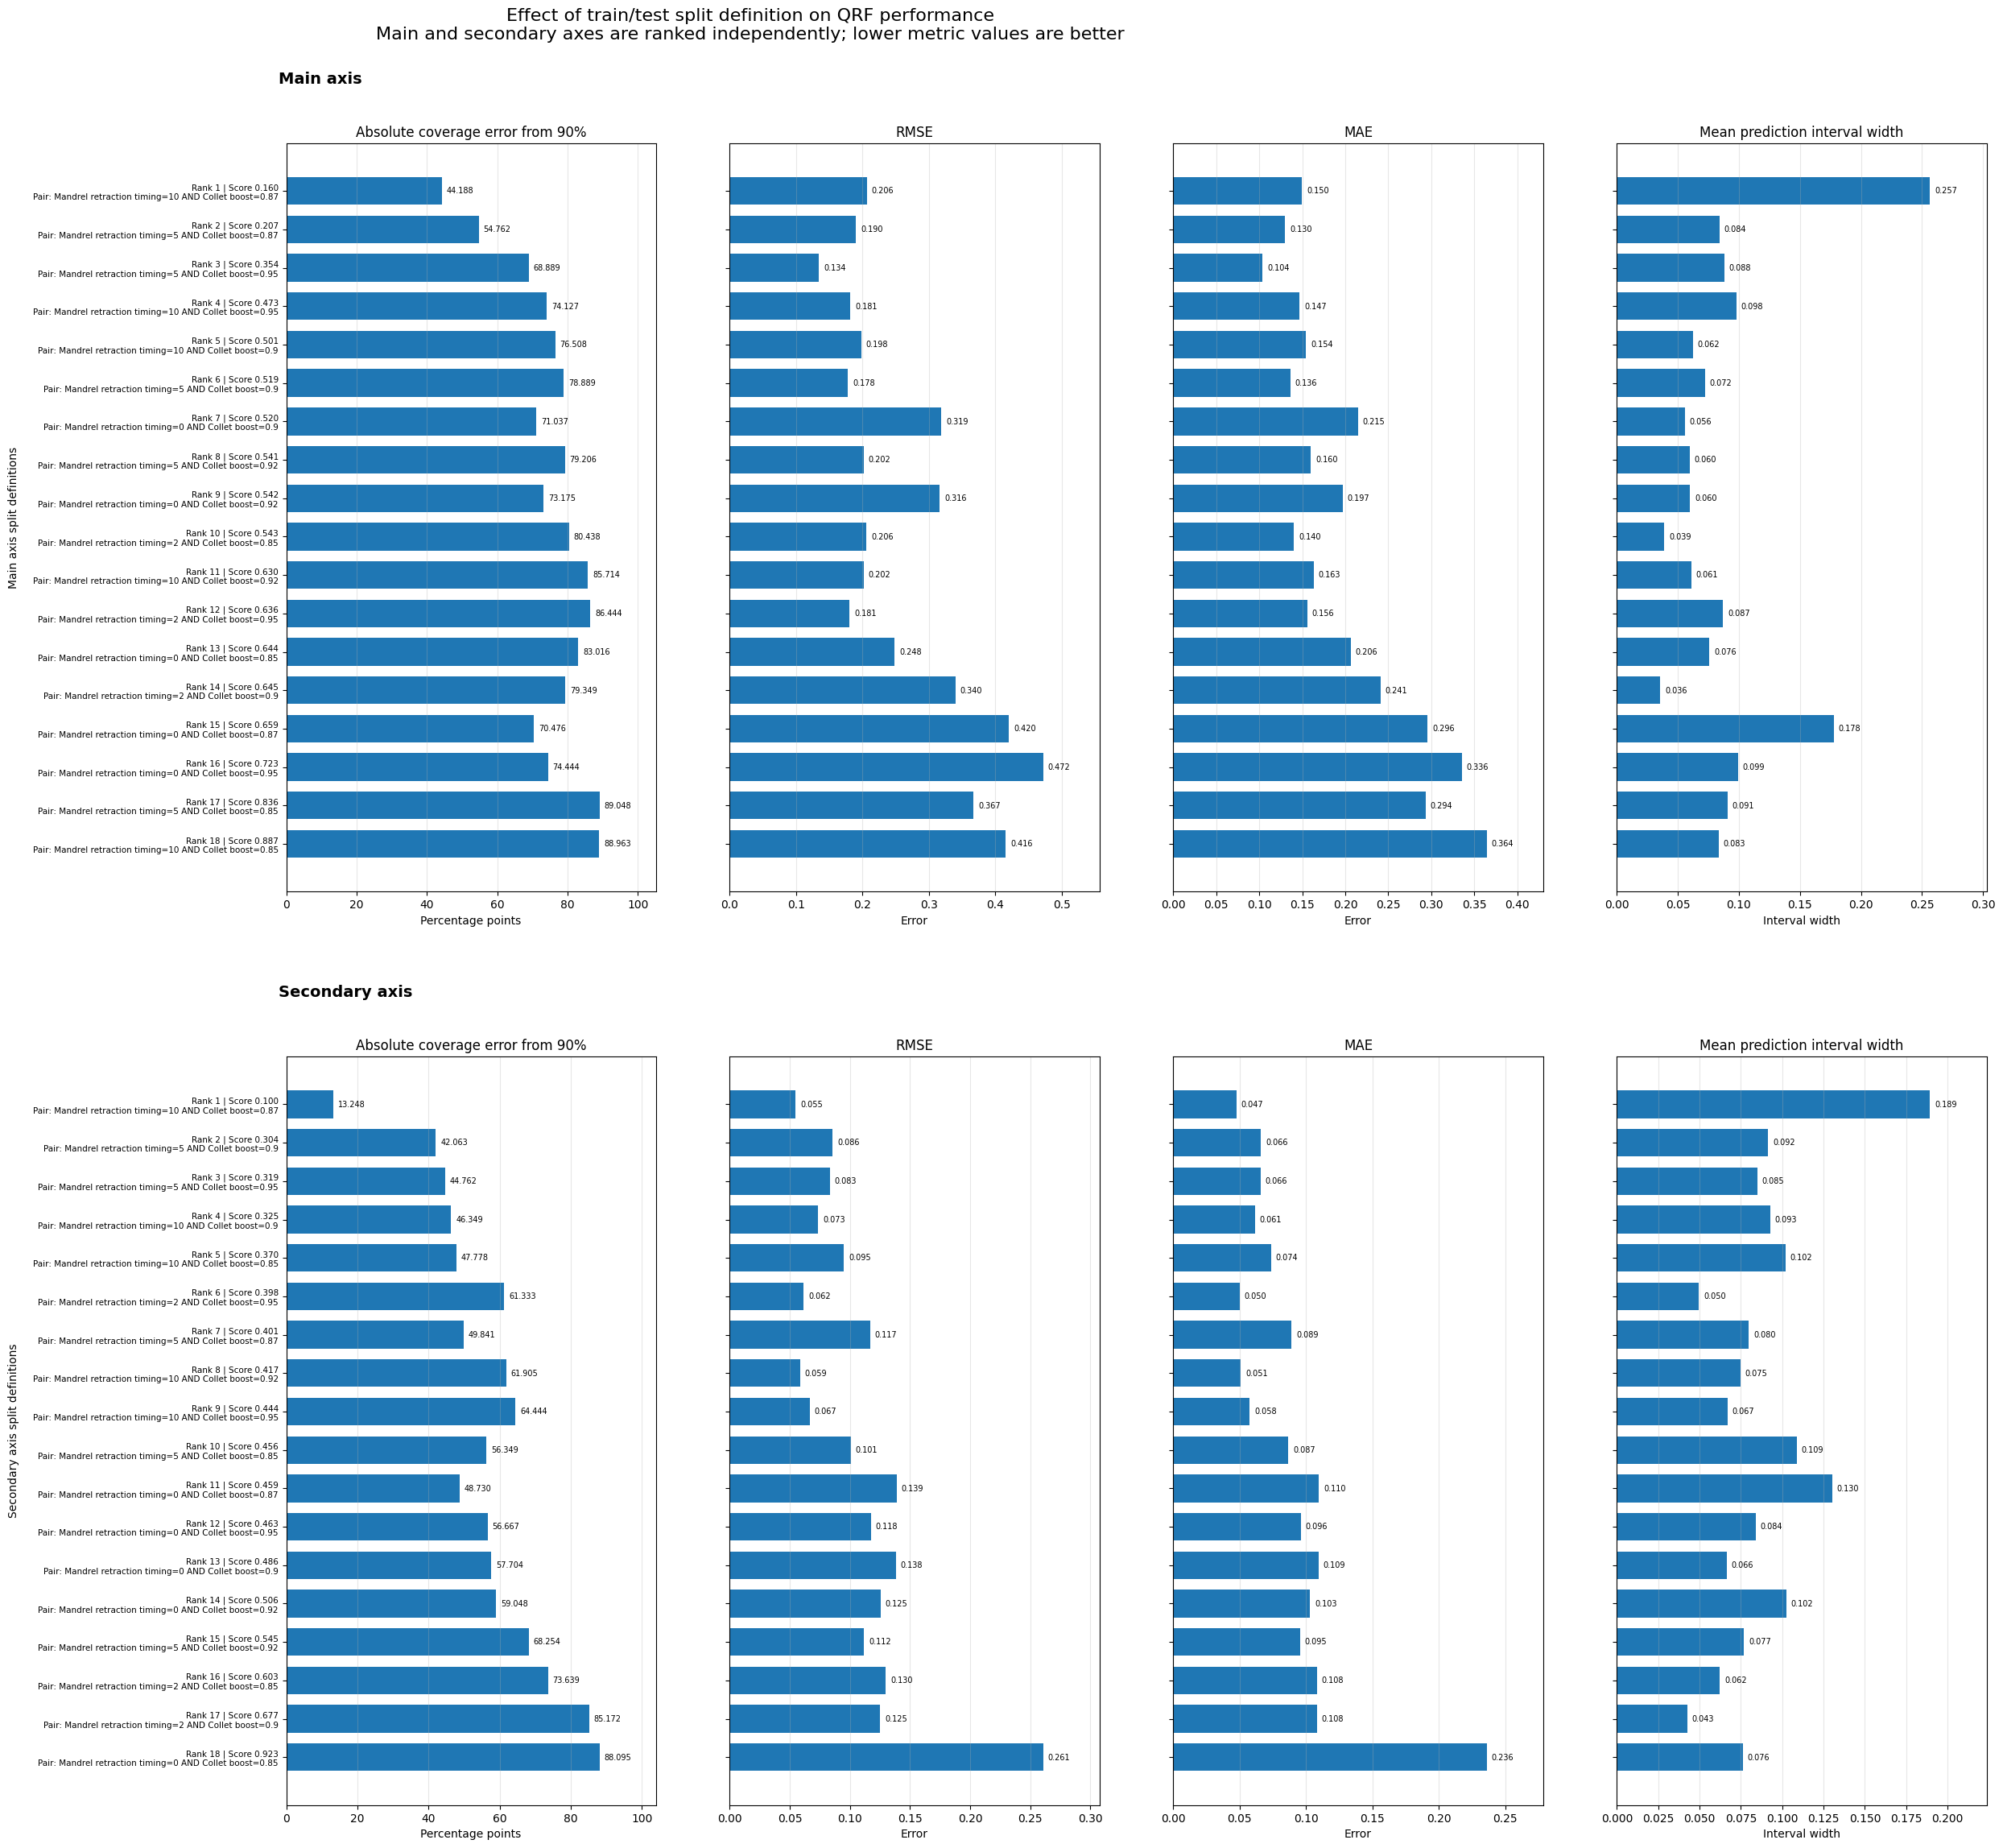

In [5]:
from mode.experiments.plot import (
    plot_split_metric_comparison,
)

SPLIT_METADATA_PATH = (
    REPO_ROOT
    / config["paths"]["split_metadata"]
)

split_metric_df = (
    plot_split_metric_comparison(
        split_metadata=SPLIT_METADATA_PATH,
        wrap_width=68,
        figsize=(32, 24),
    )
)

# Main and secondary QRF convergence

The two target axes are evaluated separately. The table reports the
QRF-ranking components used to explain why a split with higher coverage
may still receive a worse overall rank.

In [6]:
CONVERGENCE_CONFIG_PATH = (
    QRF_ROOT
    / "configs"
    / "tree_convergence.yaml"
)

convergence_config = load_config(
    config_path=CONVERGENCE_CONFIG_PATH,
    project_root=REPO_ROOT,
)

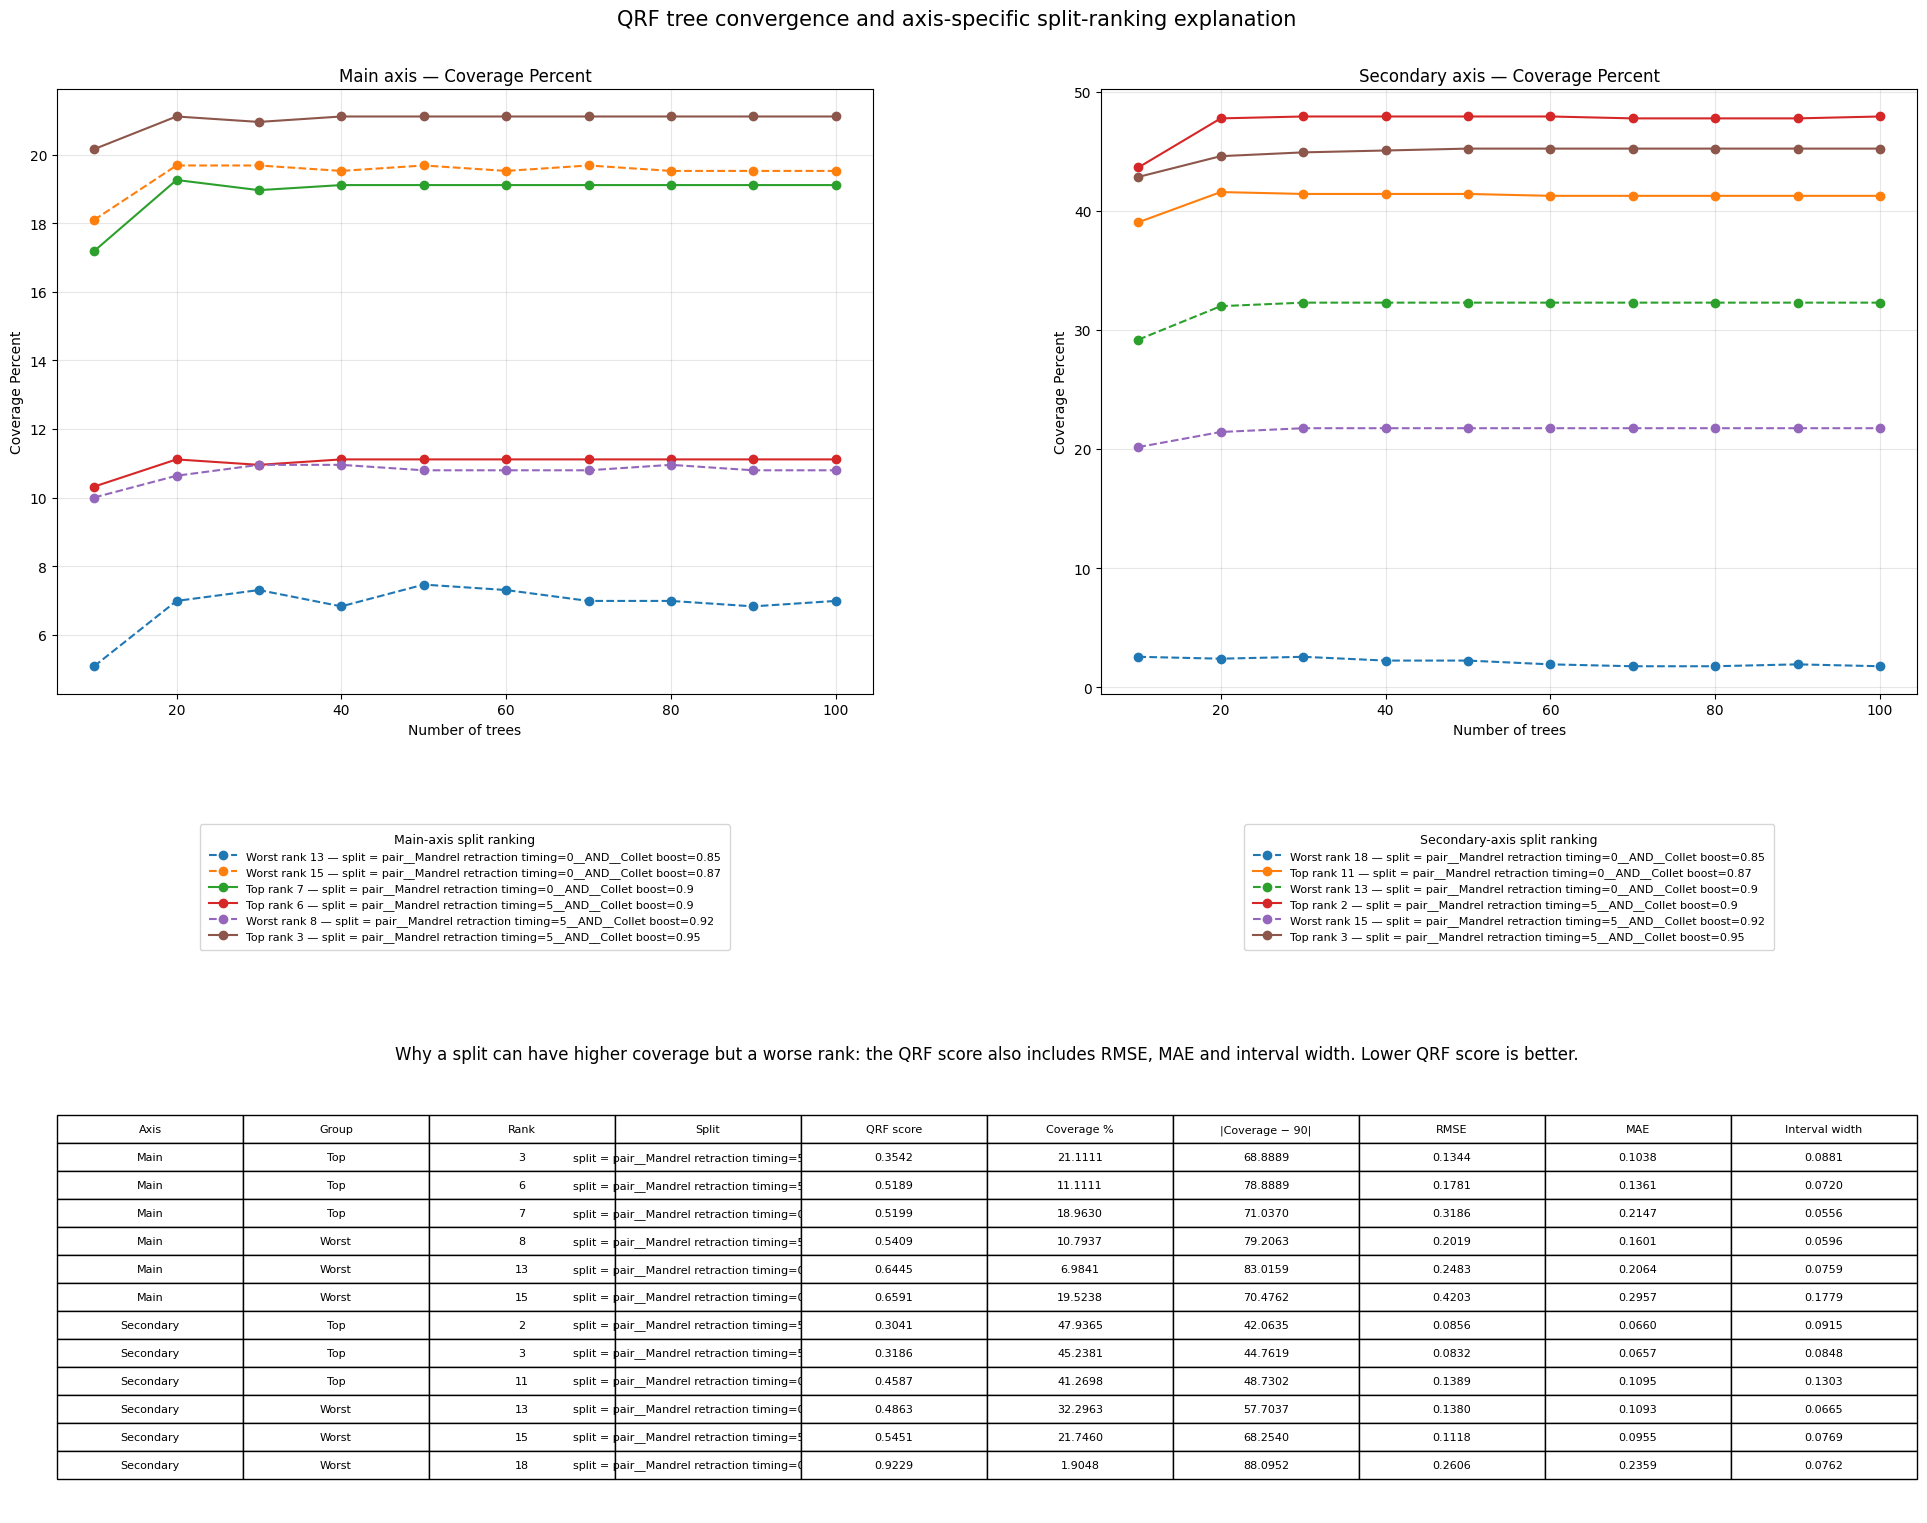

In [7]:
from mode.experiments.plot import (
    plot_main_secondary_convergence_with_ranking,
)

SPLIT_METADATA_PATH = (
    REPO_ROOT
    / convergence_config["paths"]["split_metadata"]
)

ranking_explanation_df = (
    plot_main_secondary_convergence_with_ranking(
        metrics_df=metrics_df,
        split_metadata=SPLIT_METADATA_PATH,
        metric="coverage_percent",
        top_n=3,
        worst_n=3,
    )
)

### RMSE plot

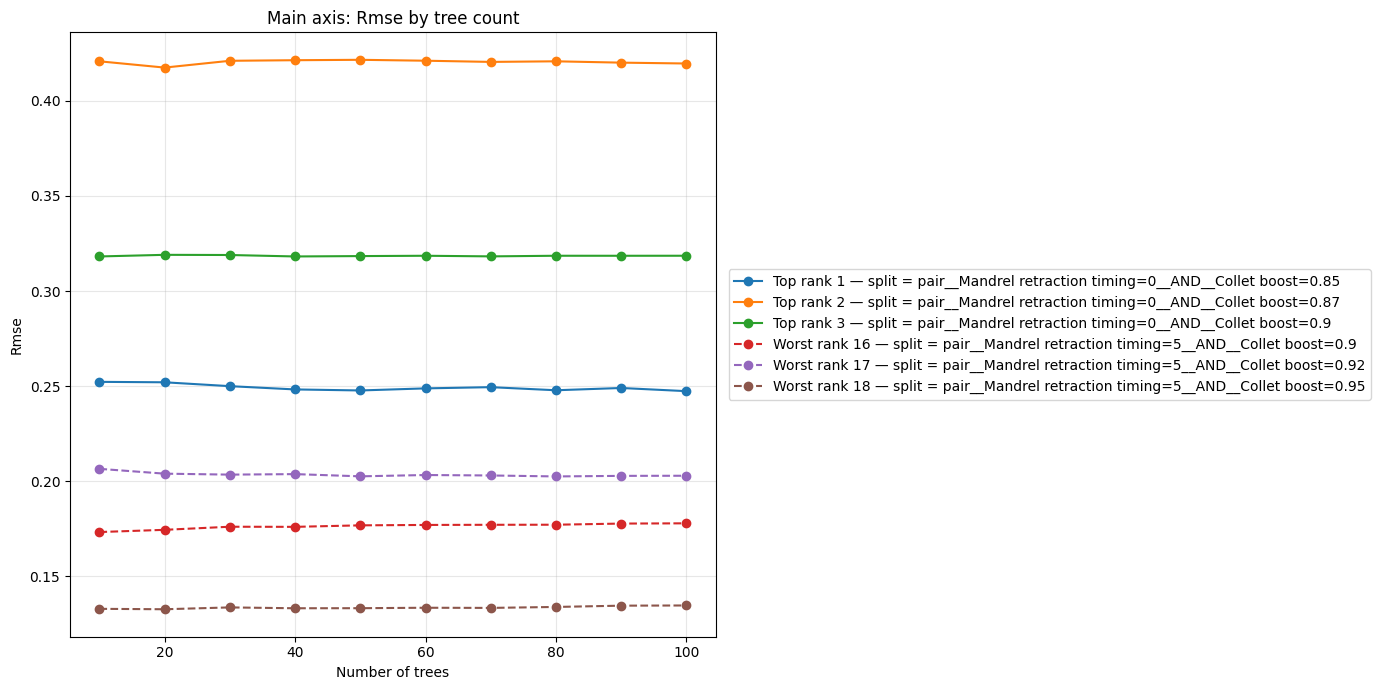

,split_index,split_rank,split_name,rank_group
0,0,1,split = pair__Mandrel retraction timing=0__AND...,Top
1,1,2,split = pair__Mandrel retraction timing=0__AND...,Top
2,2,3,split = pair__Mandrel retraction timing=0__AND...,Top
3,15,16,split = pair__Mandrel retraction timing=5__AND...,Worst
4,16,17,split = pair__Mandrel retraction timing=5__AND...,Worst
5,17,18,split = pair__Mandrel retraction timing=5__AND...,Worst


In [8]:
plot_metric_by_tree_count(
    metrics_df=metrics_df,
    metric="rmse",
    axis="main",
)

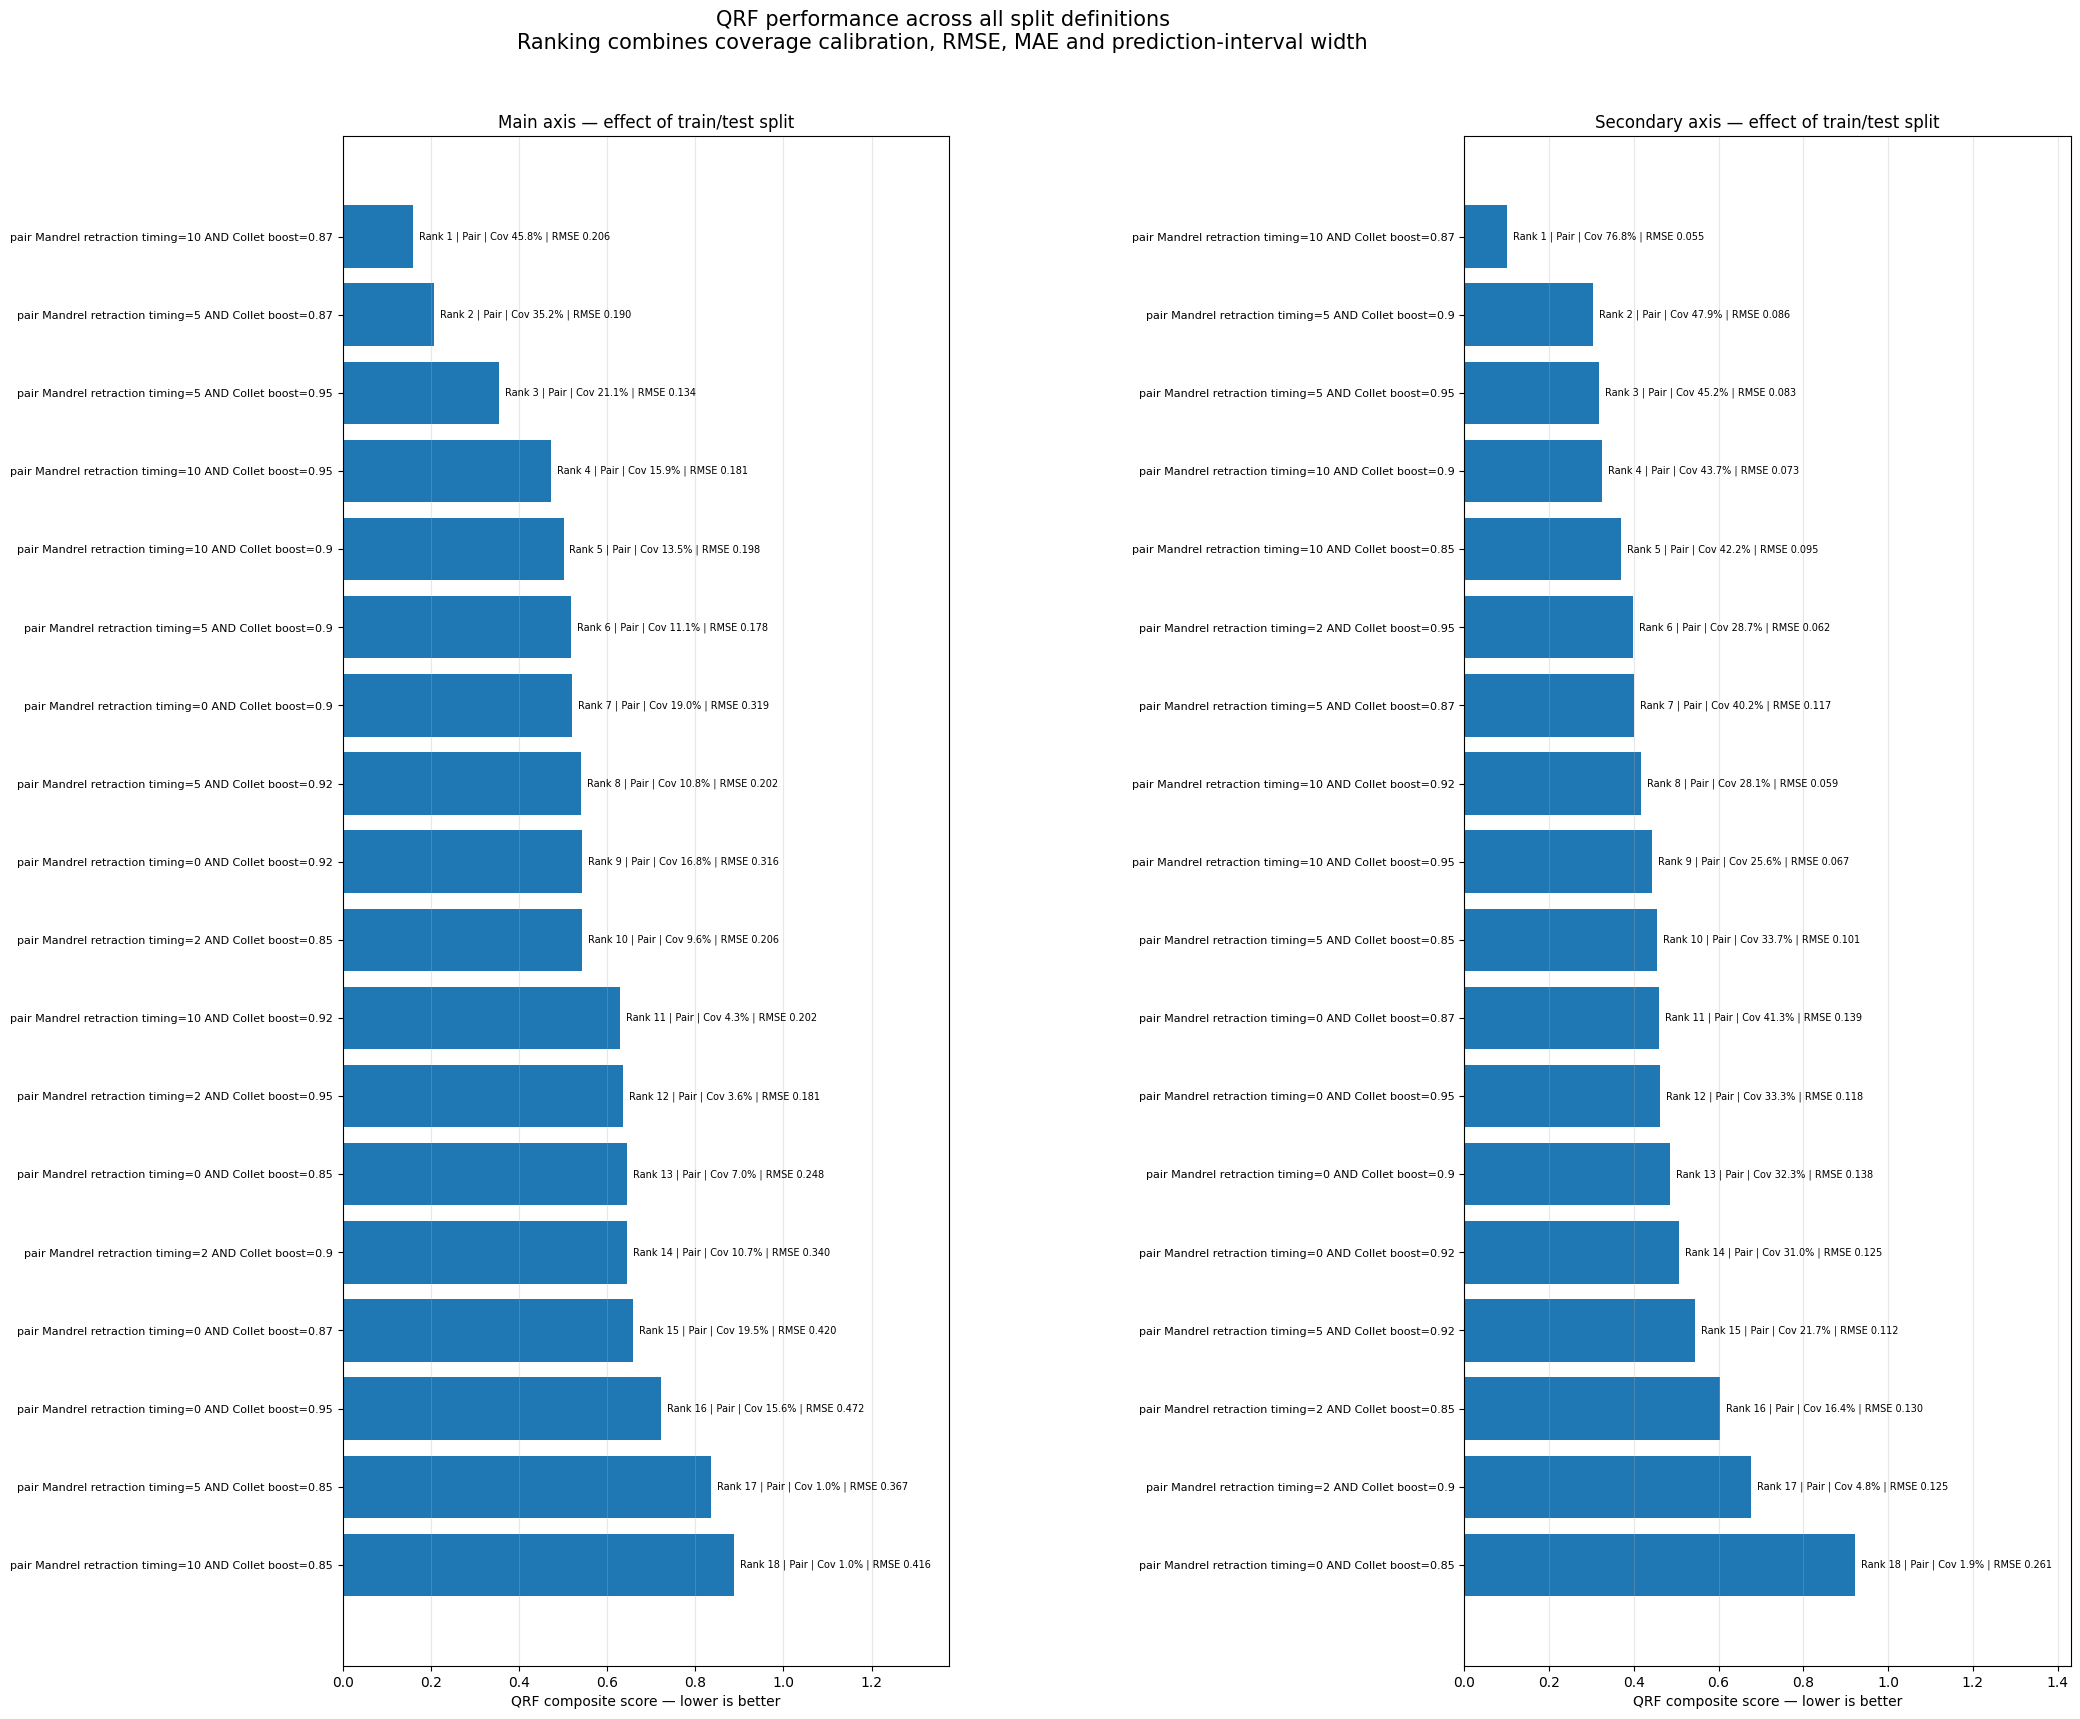

In [9]:
from mode.experiments.plot import (
    plot_all_split_effects,
)

SPLIT_METADATA_PATH = (
    REPO_ROOT
    / config["paths"]["split_metadata"]
)

all_split_effects_df = plot_all_split_effects(
    split_metadata=SPLIT_METADATA_PATH,
)

### one prediction interval

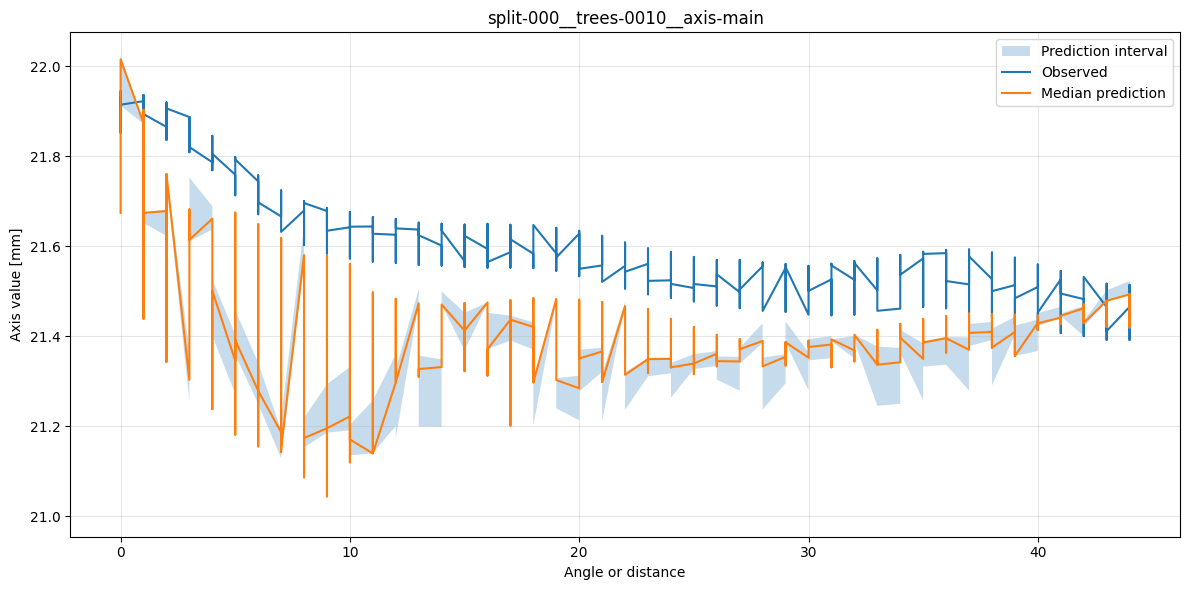

In [10]:
selected_run_id = metrics_df.iloc[0]["run_id"]

plot_prediction_interval(
    predictions_df=predictions_df,
    run_id=selected_run_id,
)